![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [148]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz, DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [27]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [28]:
# Celda 1.1
season = bikes.groupby('season')['total'].describe()
season

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [29]:
# Celda 1.2
hour = bikes.groupby('hour')['total'].describe()
hour

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


**Interpretación**

La variable **season** muestra diferencias claras en el número promedio de bicicletas alquiladas. El verano (3) presenta el mayor promedio de alquileres con 234 bicicletas por hora, seguido del spring (2) con 215 y fall (4) con 199. Por el contrario, el invierno (1) registra el menor promedio con 116, lo que indica que dependiendo de la estación hay una influencia significativa sobre la demanda. Además, los percentiles confirman esta tendencia, ya que por ejemplo los percentiles en verano son considerablemente mayores que en invierno, evidenciando mayor uso en temporadas cálidas.

Respecto a la variable **hour**, se observan patrones claros a lo largo del día. La demanda es baja durante la madrugada, alcanzando su mínimo entre las 3:00 y 5:00 a.m.. Posteriormente, se presenta un primer pico alrededor de las 7:00 - 9:00 a.m., con un promedio máximo a las 8:00 a.m. (362), lo cual coincide con horarios laborales. Luego, la demanda disminuye ligeramente al mediodía y vuelve a aumentar en la tarde, alcanzando el mayor pico del día entre las 5:00 y 6:00 p.m., con promedios de 468 y 430 respectivamente. Este comportamiento indica que el uso de bicicletas está fuertemente asociado a los horarios de desplazamiento hacia y desde el trabajo.


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

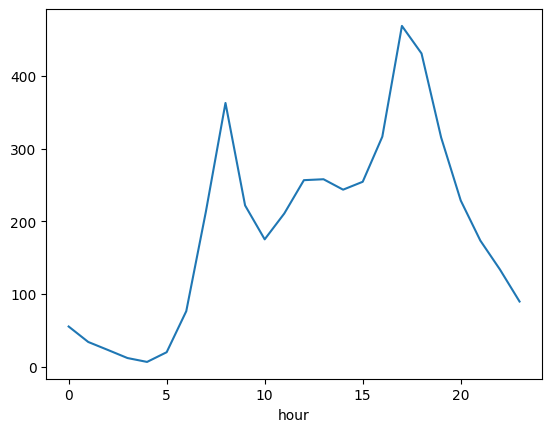

In [30]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: title={'center': 'Promedio de bicicletas alquiladas por hora - Invierno'}, xlabel='hour'>

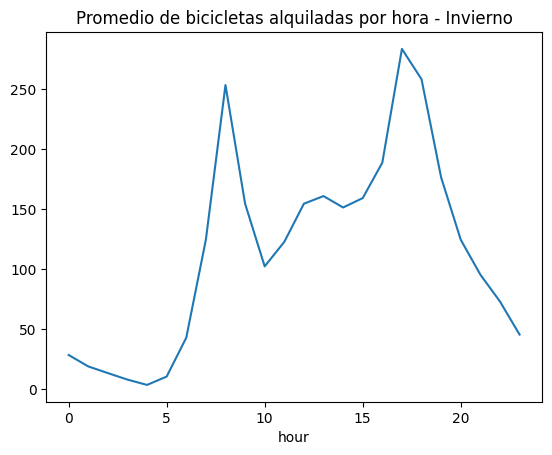

In [31]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot(
    title='Promedio de bicicletas alquiladas por hora - Invierno'
)

<Axes: title={'center': 'Promedio de bicicletas alquiladas por hora - Verano'}, xlabel='hour'>

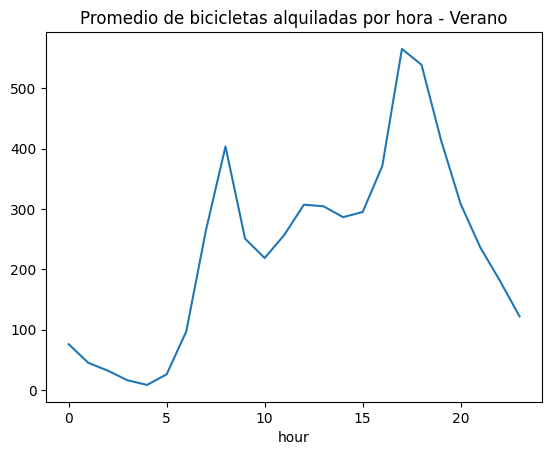

In [32]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot(
    title='Promedio de bicicletas alquiladas por hora - Verano'
)

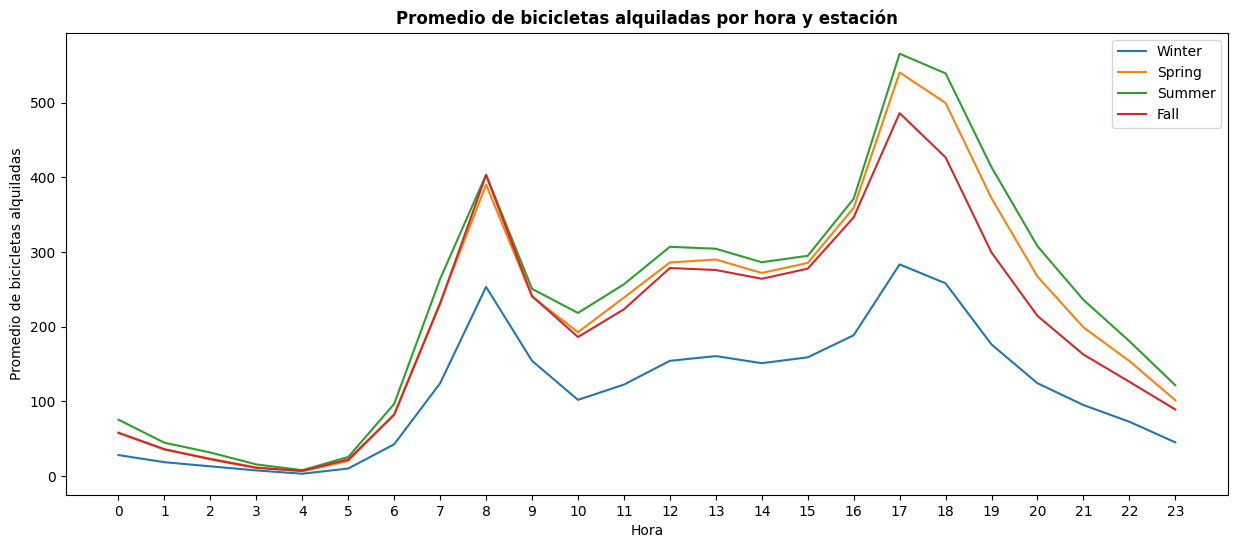

In [33]:
# Celda 2.4 - Plus (Graficar todas al mismo tiempo)
bikes.groupby(['hour','season'])['total'].mean().unstack().plot(figsize=(15,6))

plt.title('Promedio de bicicletas alquiladas por hora y estación',fontweight='bold')
plt.xlabel('Hora')
plt.xticks(range(24))
plt.ylabel('Promedio de bicicletas alquiladas')
plt.legend(['Winter','Spring','Summer','Fall'])
plt.show()

**Interpretación**

Se observa un patrón similar en las cuatro estaciones, con dos picos claros de demanda: uno en la mañana (alrededor de las 8:00 a.m.) y otro más pronunciado en la tarde (5:00–6:00 p.m.), lo que indica que el uso de bicicletas está asociado a los horarios laborales.

Aunque el verano presenta los valores promedio más altos en la mayoría de las horas, su comportamiento es muy similar al de primavera y otoño, ya que las tres estaciones siguen prácticamente la misma tendencia a lo largo del día, con diferencias principalmente en la magnitud. En contraste, winter muestra valores considerablemente más bajos en todas las horas. Esto indica que, si bien las condiciones climáticas influyen en el número de alquileres, el patrón de uso horario se mantiene consistente entre las 4 estaciones.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [111]:
# Celda 3

# Separar X y Y
XTotal = bikes[["season", "hour"]]
yTotal = bikes["total"]

# Renombrar valores de season
XTotal["season"] = XTotal["season"].map({
    1: "winter",
    2: "spring",
    3: "summer",
    4: "fall"
})

# Convertir season en categórica (dummies)
XTotal = pd.get_dummies(XTotal, columns=["season"], drop_first=True)

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(XTotal, yTotal, test_size=0.33, random_state=0)

print("Train shape:", X_train_reg.shape)
print("Test shape:", X_test_reg.shape)

#Estimación modelo en la muestra train
reg = LinearRegression()
reg.fit(X_train_reg, y_train_reg)

# Coeficientes e intercepto
print("\nCoeficientes estimados\n")
coeficientes = pd.DataFrame({"Variable": X_train_reg.columns,"Coeficiente": reg.coef_})
print(coeficientes)
print("Intercepto:", reg.intercept_)


Train shape: (7293, 4)
Test shape: (3593, 4)

Coeficientes estimados

        Variable  Coeficiente
0           hour    10.628739
1  season_spring    13.660378
2  season_summer    31.771274
3  season_winter   -87.247390
Intercepto: 77.68431903138855


**Interpretación de los coeficientes**

- **Intercepto (77.68):** Es el número promedio de bicicletas alquiladas cuando la hora es 0 y la estación corresponde a la categoría base (fall), manteniendo constantes las demás variables.

- **hour (10.63):** En promedio, por cada hora adicional del día, el número de bicicletas alquiladas aumenta en aproximadamente 10.6 bicicletas, manteniendo constantes las demás variables.

Respecto a las estaciones, los coeficientes representan la diferencia en el número promedio de bicicletas alquiladas con respecto a la estación base (fall):

- **season_summer (31.77):** En verano se alquilan en promedio 31.8 bicicletas más que en **otoño**, manteniendo constantes las demás variables.
- **season_spring (13.66):** En primavera se alquilan en promedio 13.7 bicicletas más que en **otoño**, manteniendo constantes las demás variables.
- **season_winter (-87.25):** En invierno se alquilan en promedio 87.2 bicicletas menos que en **otoño**, manteniendo constantes las demás variables

**Limitaciones de la regresión lineal en este caso**

La principal limitación es que la regresión lineal asume una relación lineal entre la variable hour y el número de bicicletas alquiladas, lo cual no se cumple en este caso. Como se observó en los gráficos, la demanda presenta dos picos claros en la mañana y la tarde, lo que implica un comportamiento no lineal que el modelo no puede capturar adecuadamente.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [112]:
# Celda 4

# Separar X y Y (Los árboles de regresión no requieren la creación de variables dummy)
X_tree = bikes[["season", "hour"]]
y_tree = bikes["total"]

#Split
X_train, X_test, y_train, y_test = train_test_split(X_tree, y_tree, test_size=0.33, random_state=0)

# Función MSE como criterio en problemas de regresión para hacer cada split del árbol
def mse(y):
    return np.mean((y - y.mean())**2)

# Función para calcular MSE del split
def mse_split(x, y, split):
    
    left = y[x < split]
    right = y[x >= split]
    
    # Evitar divisiones inválidas
    if len(left) == 0 or len(right) == 0:
        return np.inf
    
    mse_left = mse(left)
    mse_right = mse(right)
    mse_total = (len(left)/len(y))*mse_left + (len(right)/len(y))*mse_right
    
    return mse_total

# Definición de la función best_split para calcular cuál es la mejor variable y punto de corte para hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    best_split = [0, 0, np.inf]  # j, split, score
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            score = mse_split(X.iloc[:, j], y, split)
                        
            if score  < best_split[2]:
                best_split = [j, split, score]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol de regresión
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], level=level, split=-1, n_samples=1, score=0)
        return tree
    
    # Calcular la mejor división
    j, split, score = best_split(X, y, num_pct)
    
    # Predicción = media
    y_pred = y.mean()
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], score=score)
    
    # Revisar el criterio de parada 
    if score < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree):
    
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
            
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted


In [122]:
#Entrenar arbol con train
tree = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=3, num_pct=10)
tree

# Ejecución de función tree_predict
y_pred_test = tree_predict(X_test, tree)
print(y_pred_test)

#Cálculo del RMSE 
rmse_arbol_manual=  np.sqrt(mean_squared_error(y_test, y_pred_test))
print("RMSE Árbol manual::", rmse_arbol_manual)


[ 68.77729258 325.75501189 173.42928287 ... 325.75501189 151.24450952
 325.75501189]
RMSE Árbol manual:: 132.60174641548863


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

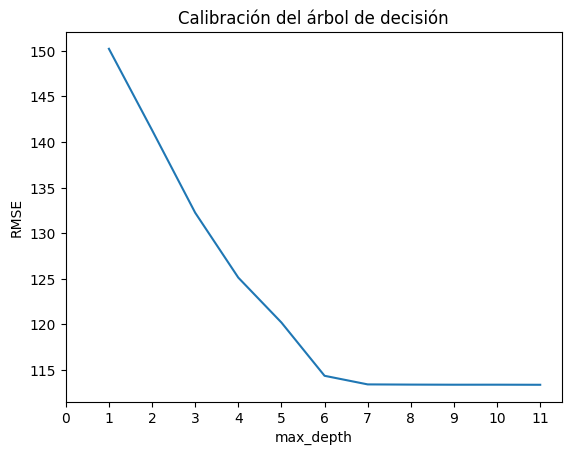

Mejor max_depth: 11
RMSE Árbol sklearn: 115.73764294643983
RMSE Regresión Lineal: 160.13875579927014


In [119]:
# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 12)

# Lista para guardar los valores del RMSE para cada valor de máxima profundidad (max_depth)
rmse_scores = []

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    # Definición del árbol de decisión usando DecisionTreeRegressor de la libreria sklearn
    regtree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    scores = cross_val_score(regtree,X_train,y_train,cv=10,scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())
    
# Gráfica max_depth versus RMSE (error del modelo)
plt.plot(max_depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Calibración del árbol de decisión')
plt.xticks(range(12))
plt.show()

# Mejor RMSE (desempeño del modelo) y su correspondiente max_depth
best_depth = max_depth_range[np.argmin(rmse_scores)]
print("Mejor max_depth:", best_depth)

# Se ajusta un árbol usando el best depth
regtree = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
regtree.fit(X_train, y_train)

# Predicción árbol de decisión sklearn en test (Punto 5)
y_pred_test_sklearn = regtree.predict(X_test)

# Predicción regresión lineal en test (Punto 3)
y_pred_test_reg = reg.predict(X_test_reg)

# RMSE árbol de decisión sklearn en test
rmse_arbol_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_test_sklearn))
print("RMSE Árbol sklearn:", rmse_arbol_sklearn)

# RMSE regresión lineal
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg))
print("RMSE Regresión Lineal:", rmse_reg)


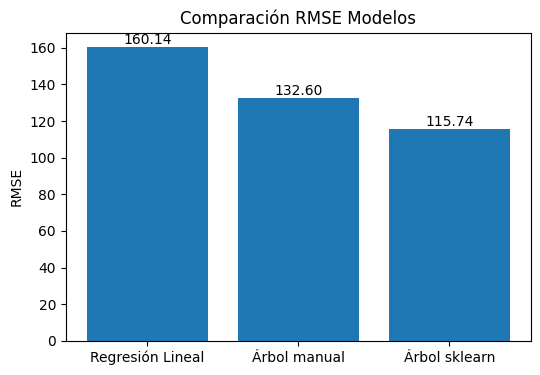

In [123]:
# Comparación RMSE
modelos = ['Regresión Lineal', 'Árbol manual','Árbol sklearn']
rmse_values = [rmse_reg, rmse_arbol_manual,rmse_arbol_sklearn]

plt.figure(figsize=(6,4))
bars = plt.bar(modelos, rmse_values)

plt.ylabel('RMSE')
plt.title('Comparación RMSE Modelos')

# Etiquetas de datos
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

**Interpretación**

El árbol de decisión implementado con la librería sklearn presenta el menor RMSE, seguido del árbol manual y finalmente la regresión lineal, lo que indica que el árbol sklearn tiene el mejor desempeño predictivo para estimar la variable "total". La regresión lineal presenta el mayor error, lo que indica que la relación entre las variables "season" y "hour" con la variable objetivo no es completamente lineal.

El árbol manual mejora considerablemente el desempeño frente a la regresión lineal, lo que confirma que los modelos basados en árboles capturan mejor este tipo de relaciones. Sin embargo, el árbol de sklearn obtiene el mejor resultado debido a que permite calibrar el parámetro de profundidad máxima (max_depth) mediante validación cruzada, seleccionando el valor que minimiza el RMSE. De esta manera, el modelo optimiza su complejidad logrando un mejor desempeño predictivo para el número de bicicletas alquiladas.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [129]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [132]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [133]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4500, 59)
Test shape: (1500, 59)


### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

### 6.1. Árbol de decisión


Mejor accuracy y max_depth (0.6308888888888888, 2)
Accuracy Árbol: 0.6453333333333333
F1-Score Árbol: 0.6448598130841121


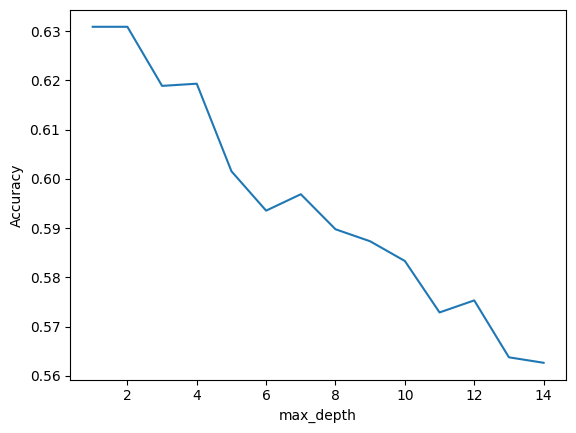

In [167]:
# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 15)

# Lista para guardar los valores del accuracy para cada valor de máxima profundidad (max_depth)
accuracy_scores = []

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    # Definición del árbol de decisión usando DecisionTreeClassifier de la libreria sklearn
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    accuracy_scores.append(cross_val_score(clf, X_train,y_train , cv=10, scoring='accuracy').mean())

# Gráfica max_depth versus Accuracy (error del modelo)
plt.plot(max_depth_range, accuracy_scores)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')

# Mejor accuracy (desempeño del modelo) y su correspondiente max_depth
max_depth=sorted(zip(accuracy_scores, max_depth_range))[::-1][0]
print("\nMejor accuracy y max_depth",max_depth)

best_depth = max_depth[1]

# max_depth=2 fue el mejor, se ajusta un árbol usando este valor 
clf = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
clf.fit(X_train,y_train)

# Predicción árbol de decisión usando muestra de test
y_pred_test = clf.predict(X_test)

# Accuracy y F1 Score en test
accuracy_test_arbol = accuracy_score(y_test, y_pred_test)
f1_test_arbol = f1_score(y_test, y_pred_test)
print("Accuracy Árbol:", accuracy_test_arbol)
print("F1-Score Árbol:", f1_test_arbol)

### 6.2. Regresión logística

In [168]:
#Estimación de regresión logistica en train
clfRegLog= LogisticRegression(random_state=0,max_iter=10000)
clfRegLog.fit(X_train,y_train)

#Predicción en test
prediccionesRegLog=clfRegLog.predict(X_test)

# Accuracy y F1 Score en test
accuracy_test_lreg = accuracy_score(y_test, prediccionesRegLog)
f1_test_lreg = f1_score(y_test, prediccionesRegLog)
print("Accuracy Regresión logística:", accuracy_test_lreg)
print("F1-Score Regresión logística:", f1_test_lreg)


Accuracy Regresión logística: 0.622
F1-Score Regresión logística: 0.6043265875785067


### 6.3 Comparación de métricas de ambos modelos

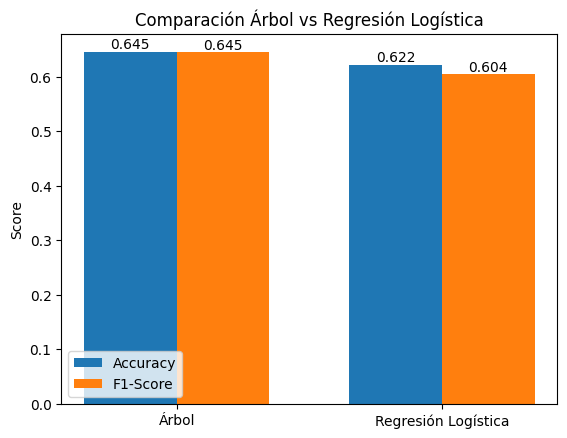

In [ ]:
# Valores
modelos = ['Árbol', 'Regresión Logística']
accuracy = [accuracy_test_arbol, accuracy_test_lreg]
f1 = [f1_test_arbol, f1_test_lreg]

x = np.arange(len(modelos))
width = 0.35

bars1 = plt.bar(x - width/2, accuracy, width, label='Accuracy')
bars2 = plt.bar(x + width/2, f1, width, label='F1-Score')
plt.xticks(x, modelos)
plt.ylabel('Score')
plt.title('Comparación Árbol vs Regresión Logística')
plt.legend()

# Etiquetas de datos
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom'
        )

plt.show()

**Interpretación**

El árbol de decisión presenta un mejor desempeño que la regresión logística, obteniendo valores ligeramente superiores tanto en Accuracy como en F1-score. Esto sugiere que el árbol logra capturar mejor las relaciones entre las variables predictoras y la variable objetivo **Popularidad**. Sin embargo, es importante aclarar que la diferencia entre ambos modelos no es muy grande, lo que indica que la regresión logística también presenta un desempeño similar. Esto puede deberse a que la estructura de los datos no es altamente compleja, permitiendo que ambos modelos logren resultados comparables.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

### 7.1 Bootstrap (100) árboles de decisión con max_depth=6

In [188]:
# Creación de 100 muestras de bootstrap
np.random.seed(123)
n_estimators = 100

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]
seeds = np.random.randint(1, 10000, size=n_estimators)

trees = {}
for i in range(n_estimators):
    trees[i] = DecisionTreeClassifier(max_features="sqrt", max_depth=6, random_state=seeds[i])
    trees[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

# Predicción para los datos del set de test con cada modelo
y_pred_df_tree1 = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
for i in range(n_estimators):
    y_pred_df_tree1.iloc[:, i] = trees[i].predict(X_test)

y_pred_df_tree1

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
1483,1,1,1,0,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
2185,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,0
2520,0,1,1,1,0,1,0,0,1,1,...,0,1,1,1,1,1,0,1,1,1
3721,1,1,1,1,1,1,0,1,1,1,...,0,1,1,1,1,1,1,1,0,1
3727,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,1,1,1,1,0,0,1,1,1,0,...,0,0,0,1,0,1,0,1,0,0
5166,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2227,1,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
5684,0,0,0,0,0,0,0,1,0,0,...,0,1,0,1,0,0,1,0,1,0


In [193]:
# Votación mayoritaria
y_pred_tree1 = (y_pred_df_tree1.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Desempeño al hacer votación mayoritaria
accuracy_test_tree1=accuracy_score(y_pred_tree1, y_test)
f1_test_tree1=f1_score(y_pred_tree1, y_test)
print("Accuracy Árbol 1:", accuracy_test_tree1)
print("F1-Score Árbol 1:", f1_test_tree1)

Accuracy Árbol 1: 0.664
F1-Score Árbol 1: 0.6585365853658537


### 7.2 Bootstrap (100) árboles de decisión con min_samples_leaf=5

In [194]:
# Creación de 100 muestras de bootstrap
np.random.seed(123)
n_estimators = 100

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]

# Entrenamiento de 100 modelos con las 100 muestras boostrap
seeds = np.random.randint(1, 10000, size=n_estimators)
trees = {}
for i in range(n_estimators):
    trees[i] = DecisionTreeClassifier(max_features="sqrt", max_depth=None, random_state=seeds[i],min_samples_leaf=5)
    trees[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

# Predicción para los datos del set de test con cada modelo
y_pred_df_tree2 = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
for i in range(n_estimators):
    y_pred_df_tree2.iloc[:, i] = trees[i].predict(X_test)

y_pred_df_tree2

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
1483,0,1,1,1,1,1,0,0,0,1,...,0,1,1,1,1,1,1,1,1,0
2185,1,0,1,1,1,1,1,1,1,1,...,1,0,1,1,0,0,1,0,1,1
2520,0,1,1,0,0,0,1,1,0,1,...,0,1,0,0,0,1,0,0,1,0
3721,0,1,1,1,1,1,1,0,1,1,...,1,0,1,1,1,0,1,0,1,0
3727,0,1,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,0,1,0,0,1,0,0,0,0,1,...,1,0,0,1,1,0,0,1,0,0
5166,0,1,1,0,1,0,1,0,1,0,...,0,1,1,0,1,1,1,0,0,0
2227,1,1,1,1,0,0,1,1,1,0,...,0,1,0,0,0,1,1,1,0,1
5684,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,1,1,1


In [195]:
# Votación mayoritaria
y_pred_tree2 = (y_pred_df_tree2.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Desempeño al hacer votación mayoritaria
accuracy_test_tree2=accuracy_score(y_pred_tree2, y_test)
f1_test_tree2=f1_score(y_pred_tree2, y_test)
print("Accuracy Árbol 2:", accuracy_test_tree2)
print("F1-Score Árbol 2:", f1_test_tree2)

Accuracy Árbol 2: 0.6546666666666666
F1-Score Árbol 2: 0.6480978260869565


### 7.3 Bootstrap (100) regresiones logísticas

In [197]:
# Creación de 100 muestras de bootstrap
np.random.seed(123)
n_estimators = 100

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]

# Entrenamiento de 100 modelos con las 100 muestras bootstrap
seeds = np.random.randint(1, 10000, size=n_estimators)

logreg = {}
for i in range(n_estimators):
    logreg[i] = LogisticRegression(random_state=seeds[i], max_iter=1000)
    logreg[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

# Predicción para los datos del set de test con cada modelo
y_pred_df_log = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
for i in range(n_estimators):
    y_pred_df_log.iloc[:, i] = logreg[i].predict(X_test)

y_pred_df_log

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
1483,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2185,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2520,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3721,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3727,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5166,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2227,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
5684,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Votación mayoritaria
y_pred_log = (y_pred_df_log.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Desempeño al hacer votación mayoritaria
accuracy_test_log=accuracy_score(y_pred_log, y_test)
f1_test_log=f1_score(y_pred_log, y_test)
print("Accuracy Regresión Logística:", accuracy_test_log)
print("F1-Score Regresión Logística:", f1_test_log)

Accuracy Árbol 2: 0.616
F1-Score Árbol 2: 0.6038514442916093


### 7.4 Ensamble final

In [199]:
# Unir predicciones de los tres modelos
y_pred_ensamble = pd.DataFrame({
    "tree1": y_pred_tree1,
    "tree2": y_pred_tree2,
    "logreg": y_pred_log
})

# Votación mayoritaria entre los tres modelos
y_pred_final = (y_pred_ensamble.sum(axis=1) >= 2).astype(np.int64)

# Evaluación del ensamble
accuracy_ensamble = accuracy_score(y_test, y_pred_final)
f1_ensamble = f1_score(y_test, y_pred_final)

print("Accuracy Ensamble:", accuracy_ensamble)
print("F1-Score Ensamble:", f1_ensamble)

Accuracy Ensamble: 0.6586666666666666
F1-Score Ensamble: 0.6521739130434783


In [ ]:
# Crear tabla de resultados
resultados = pd.DataFrame({
    "Modelo": ["Árbol 1", "Árbol 2", "Regresión Logística", "Ensamble Final"],
    "Accuracy": [accuracy_test_tree1,accuracy_test_tree2,accuracy_test_log,accuracy_ensamble],
    "F1-Score": [f1_test_tree1,f1_test_tree2,f1_test_log,f1_ensamble]
})

resultados

,Modelo,Accuracy,F1-Score
0,Árbol 1,0.664000,0.658537
1,Árbol 2,0.654667,0.648098
2,Regresión Logística,0.616000,0.603851
3,Ensamble Final,0.658667,0.652174


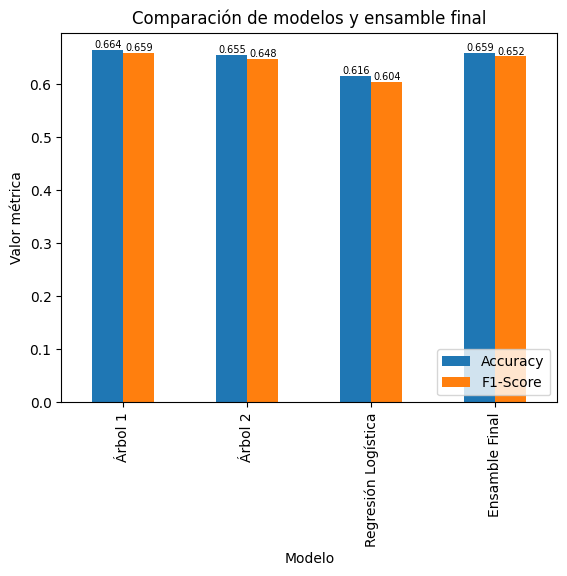

In [224]:
# Gráfico comparativo
ax = resultados.set_index("Modelo")[["Accuracy", "F1-Score"]].plot(kind="bar")

plt.title("Comparación de modelos y ensamble final")
plt.ylabel("Valor métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=90)
plt.legend(loc="lower right")

# Agregar etiquetas de datos
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f',fontsize=7)

plt.show()

**Interpretación**

El modelo Árbol 1 presenta el mejor desempeño tanto en Accuracy (0.664) como en F1-Score (0.659). El ensamble final muestra un desempeño ligeramente inferior (Accuracy 0.659, F1 0.652), aunque muy cercano al mejor modelo individual. Lo anterior indica que el ensamble no logra mejorar significativamente el rendimiento, probablemente porque el Árbol 1 ya captura adecuadamente la estructura de los datos. Por su parte, la regresión logística presenta el menor desempeño, lo que indica que la relación entre variables podría ser no lineal, favoreciendo modelos basados en árboles.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

### 8.1 Árbol 1

In [ ]:
# Observaciones fuera de la bolsa (OOB)
samples_oob = []
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors_tree1 = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = trees[i].predict(X_train.iloc[samples_oob[i]])
    errors_tree1[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

# Pesos y votación ponderada
alpha_tree1 = (1 - errors_tree1) / (1 - errors_tree1).sum()
weighted_tree1 = (y_pred_df_tree1 * alpha_tree1).sum(axis=1)

# Predicción final
y_pred_tree1_weighted = (weighted_tree1 >= 0.5).astype(np.int64)

# Métricas
accuracy_tree1_weighted = accuracy_score(y_test, y_pred_tree1_weighted)
f1_tree1_weighted = f1_score(y_test, y_pred_tree1_weighted)
print("Accuracy Árbol 1 ponderado:", accuracy_tree1_weighted)
print("F1 Árbol 1 ponderado:", f1_tree1_weighted)

Accuracy Árbol 1 ponderado: 0.6646666666666666
F1 Árbol 1 ponderado: 0.6580557443915703


### 8.2 Árbol 2

In [225]:
errors_tree2 = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = trees[i].predict(X_train.iloc[samples_oob[i]])
    errors_tree2[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

# Pesos y votación ponderada
alpha_tree2 = (1 - errors_tree2) / (1 - errors_tree2).sum()
weighted_tree2 = (y_pred_df_tree2 * alpha_tree2).sum(axis=1)

# Predicción final
y_pred_tree2_weighted = (weighted_tree2 >= 0.5).astype(np.int64)

# Métricas
accuracy_tree2_weighted = accuracy_score(y_test, y_pred_tree2_weighted)
f1_tree2_weighted = f1_score(y_test, y_pred_tree2_weighted)
print("Accuracy Árbol 2 ponderado:", accuracy_tree2_weighted)
print("F1 Árbol 2 ponderado:", f1_tree2_weighted)

Accuracy Árbol 2 ponderado: 0.654
F1 Árbol 2 ponderado: 0.6447638603696099


### 8.3 Regresiones logísticas

In [226]:
errors_log = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = logreg[i].predict(X_train.iloc[samples_oob[i]])
    errors_log[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

# Pesos y votación ponderada
alpha_log = (1 - errors_log) / (1 - errors_log).sum()
weighted_log = (y_pred_df_log * alpha_log).sum(axis=1)

# Predicción final
y_pred_log_weighted = (weighted_log >= 0.5).astype(np.int64)

# Métricas
accuracy_log_weighted = accuracy_score(y_test, y_pred_log_weighted)
f1_log_weighted = f1_score(y_test, y_pred_log_weighted)
print("Accuracy Logística ponderado:", accuracy_log_weighted)
print("F1 Logística ponderado:", f1_log_weighted)

Accuracy Logística ponderado: 0.616
F1 Logística ponderado: 0.6038514442916093


### 8.4 Ensamble Final Ponderado

In [227]:
ensamble_weighted = pd.DataFrame({
    "tree1": y_pred_tree1_weighted,
    "tree2": y_pred_tree2_weighted,
    "log": y_pred_log_weighted
})

y_pred_final_weighted = (ensamble_weighted.sum(axis=1) >= 2).astype(np.int64)

accuracy_final_weighted = accuracy_score(y_test, y_pred_final_weighted)
f1_final_weighted = f1_score(y_test, y_pred_final_weighted)
print("Accuracy Ensamble Ponderado:", accuracy_final_weighted)
print("F1 Ensamble Ponderado:", f1_final_weighted)

Accuracy Ensamble Ponderado: 0.6593333333333333
F1 Ensamble Ponderado: 0.6507177033492823


In [228]:
resultados_ponderado = pd.DataFrame({
    "Modelo":["Árbol 1 Ponderado","Árbol 2 Ponderado","Regresión Logística Ponderado","Ensamble Final Ponderado"],
    "Accuracy":[accuracy_tree1_weighted,accuracy_tree2_weighted,accuracy_log_weighted,accuracy_final_weighted],
    "F1-Score":[f1_tree1_weighted,f1_tree2_weighted,f1_log_weighted,f1_final_weighted]
})

resultados_ponderado

,Modelo,Accuracy,F1-Score
0,Árbol 1 Ponderado,0.664667,0.658056
1,Árbol 2 Ponderado,0.654000,0.644764
2,Regresión Logística Ponderado,0.616000,0.603851
3,Ensamble Final Ponderado,0.659333,0.650718


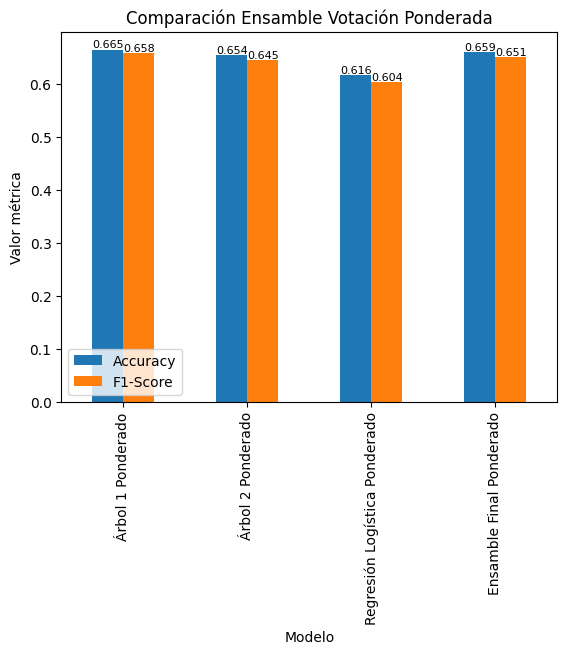

In [229]:
ax = resultados_ponderado.set_index("Modelo")[["Accuracy","F1-Score"]].plot(kind="bar")

plt.title("Comparación Ensamble Votación Ponderada")
plt.ylabel("Valor métrica")
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.show()

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

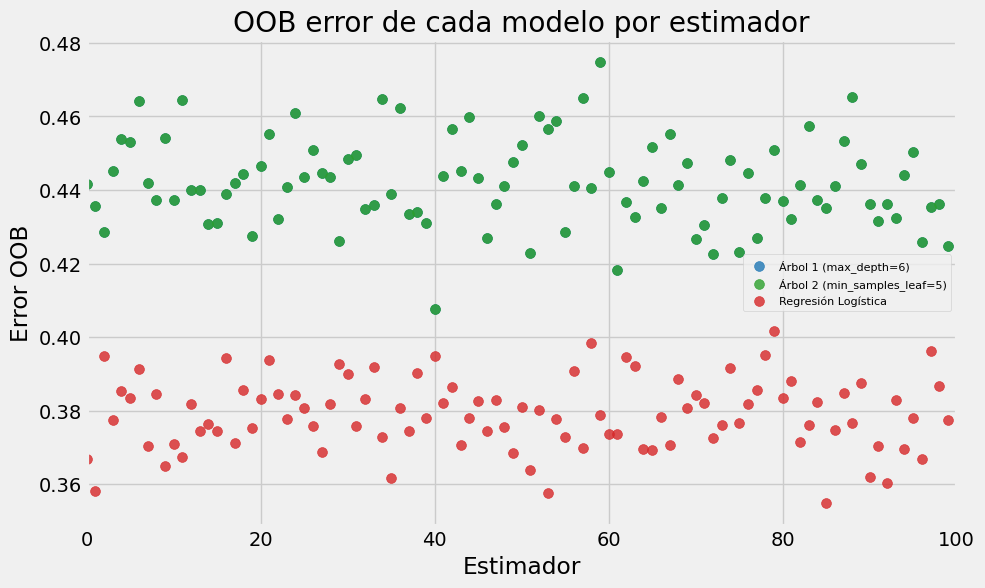

In [244]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 6))

# Scatter plot de errores OOB
plt.scatter(range(n_estimators), errors_tree1, color='#1f77b4', s=50, alpha=0.8, label='Árbol 1 (max_depth=6)')
plt.scatter(range(n_estimators), errors_tree2, color='#2ca02c', s=50, alpha=0.8, label='Árbol 2 (min_samples_leaf=5)')
plt.scatter(range(n_estimators), errors_log, color='#d62728', s=50, alpha=0.8, label='Regresión Logística')

# Límites y títulos
plt.xlim([0, n_estimators])
plt.xlabel('Estimador')
plt.ylabel('Error OOB')
plt.title('OOB error de cada modelo por estimador')
plt.legend(fontsize=8)
plt.show()

**Conclusión**

La comparación entre votación mayoritaria y votación ponderada muestra que ambos métodos produjeron resultados muy similares en este experimento. El ensamble de votación mayoritaria obtuvo un Accuracy de 0.6587 y un F1-Score de 0.6522, mientras que la votación ponderada logró 0.6593 y 0.6507 respectivamente, diferencias prácticamente despreciables. Esto refleja que los modelos individuales (dos árboles de decisión (max_depth=6 y min_samples_leaf=5)) y una regresión logística tenían desempeños relativamente cercanos, con los árboles dominando la predicción y la regresión logística aportando poco al ensamble.

La votación mayoritaria se beneficia por su simplicidad y robustez, contando todos los modelos por igual y favoreciendo no beneficiar excesivamente a un modelo que podría estar sobreajustando, mientras que la ponderada busca reflejar el desempeño de cada modelo favoreciendo a aquellos que fueron más precisos individualmente. En este caso, la ponderación no generó mejoras significativas porque los pesos de los modelos no estaban muy desbalanceados. Esto se confirma en el gráfico donde la dispersión relativamente pequeña y la proximidad de los errores explican por qué la votación ponderada no ofrece una mejora significativa frente a la mayoritaria: los pesos basados en estos errores OOB serían casi iguales para todos los modelos.

En conclusión, ambas metodologías son válidas y, teniendo en cuenta los resultados vistos, no hay una diferencia muy significativa en el desempeño. La elección entre ellas sería más relevante en escenarios donde existan modelos con métricas muy disparejas entre cada clasificador.